 Bu veri setini seçme nedenimiz video oyun sektörünün büyüklüğünü analiz etmektir.

Bu veri seti:

Oyun satışlarını (NA, EU, JP, Global)
Türleri (Genre)
Platformları (PS4, PC vb.)
Yayıncıları içerir.
Cevap aranan sorular:

En çok satan oyun türü nedir?
Hangi platformlar daha başarılı?
Bölgesel satış farkları var mı? 

Not: Bu veri seti 1980'lerden 2016 yılına kadar olan video oyunu satış verilerini kapsamaktadır. vgchartz.com sitesinden derlenen bu veriler yalnızca 100.000'in üzerinde kopya satan oyunları içermektedir. Dolayısıyla veri seti günümüzdeki oyun pazarını yansıtmamaktadır — dijital satışların yaygınlaşması, mobil oyunculuğun patlaması ve yayıncı değişimleri gibi güncel gelişmeler bu veride yer almamaktadır. Güncel pazar analizleri için daha yeni kaynaklara başvurulması önerilir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Veri Setine Bakma**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/gregorut/videogamesales/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


**Veriyi Tanıma**

In [3]:
df.shape

(16598, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [5]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


**Eksik Değer Var mı?**

In [6]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

**Eksik Verilerin Silinmesi**

In [7]:
df = df.dropna()

**Yenilenen Kayıtlar**

In [8]:
df.duplicated().sum()

np.int64(0)

**Aynı Kayıtların Tekrar edilmemesi için silinmesi**

In [9]:
df = df.drop_duplicates()

**Toplam Satışları Doğrulamak İçin**

In [10]:
df["Total_Sales"] = df["NA_Sales"] + df["EU_Sales"] + df["JP_Sales"] + df["Other_Sales"]

**Oyunları Satış Seviyesine Göre Gruplama**

In [11]:
def categorize_sales(x):
    if x > 10:
        return "High"
    elif x > 1:
        return "Medium"
    else:
        return "Low"

df["Sales_Category"] = df["Global_Sales"].apply(categorize_sales)

**En Çok Satılan Türler**

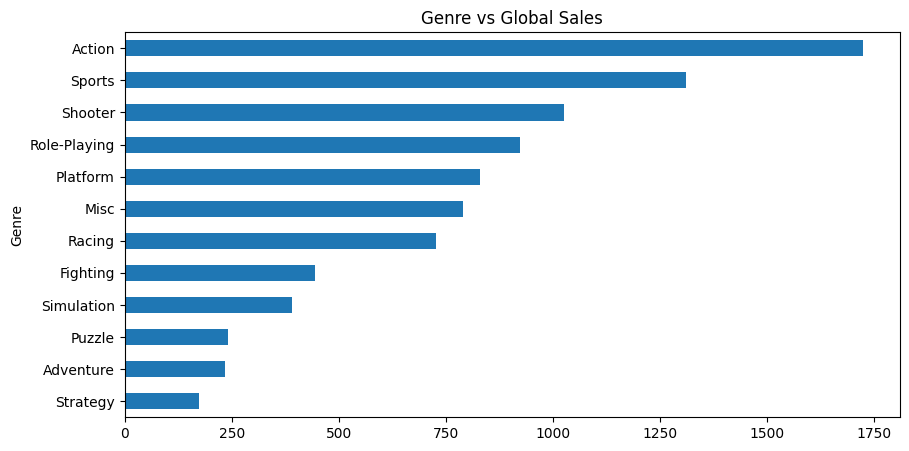

In [12]:
plt.figure(figsize=(10,5))
df.groupby("Genre")["Global_Sales"].sum().sort_values().plot(kind="barh")
plt.title("Genre vs Global Sales")
plt.show()

**Platformlara Göre Satış**

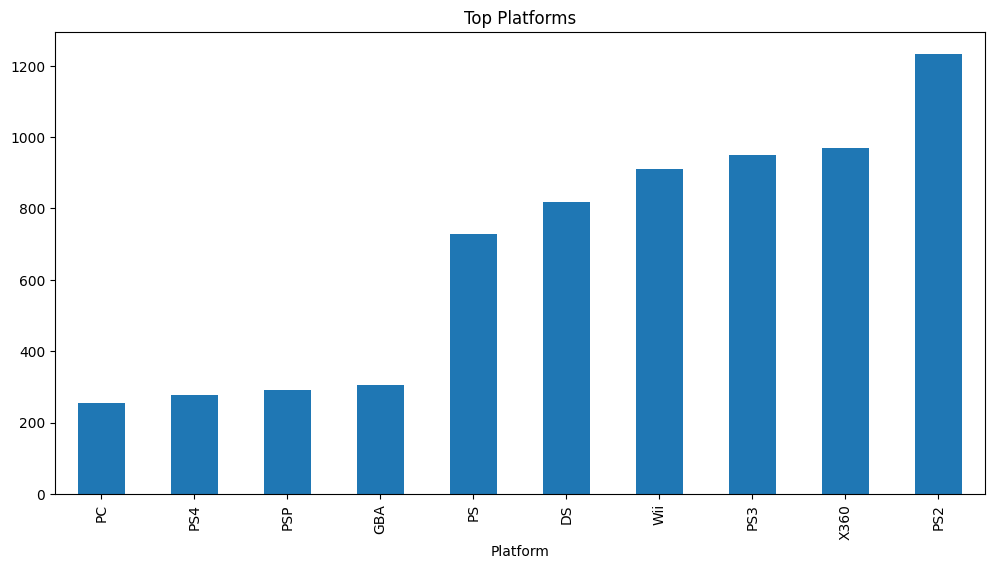

In [13]:
plt.figure(figsize=(12,6))
df.groupby("Platform")["Global_Sales"].sum().sort_values().tail(10).plot(kind="bar")
plt.title("Top Platforms")
plt.show()

**Bölgesel Olarak Satışlar**

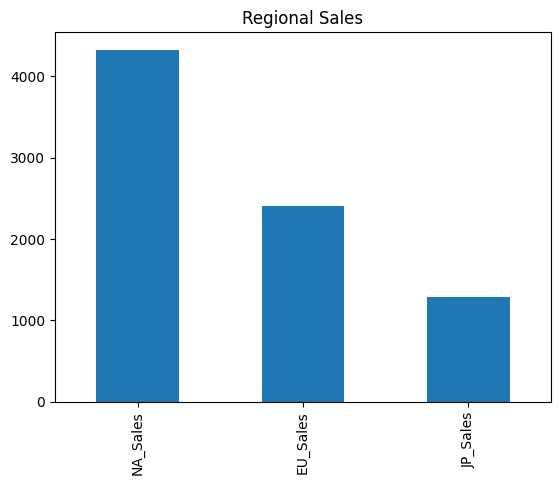

In [14]:
df[["NA_Sales","EU_Sales","JP_Sales"]].sum().plot(kind="bar")
plt.title("Regional Sales")
plt.show()

**Kategorik Satış Dağılımı**

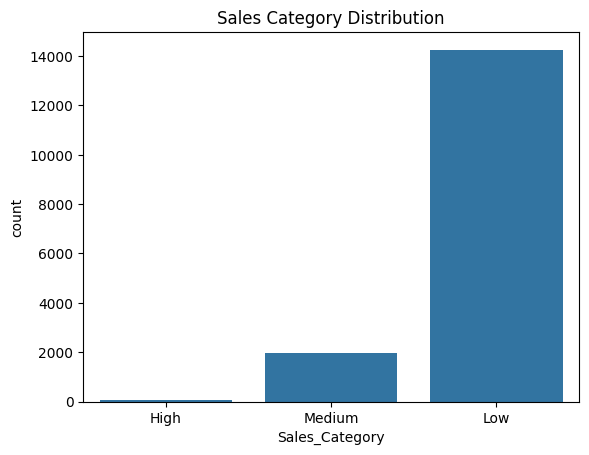

In [15]:
sns.countplot(x="Sales_Category", data=df)
plt.title("Sales Category Distribution")
plt.show()

**Yıllara Göre Satış**

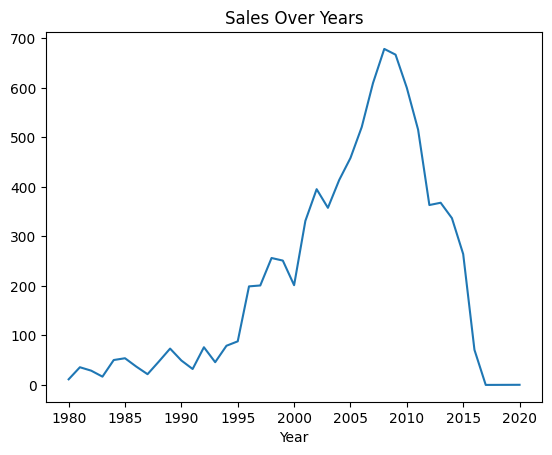

In [16]:
df.groupby("Year")["Global_Sales"].sum().plot()
plt.title("Sales Over Years")
plt.show()

**Korelasyon Matrisi**

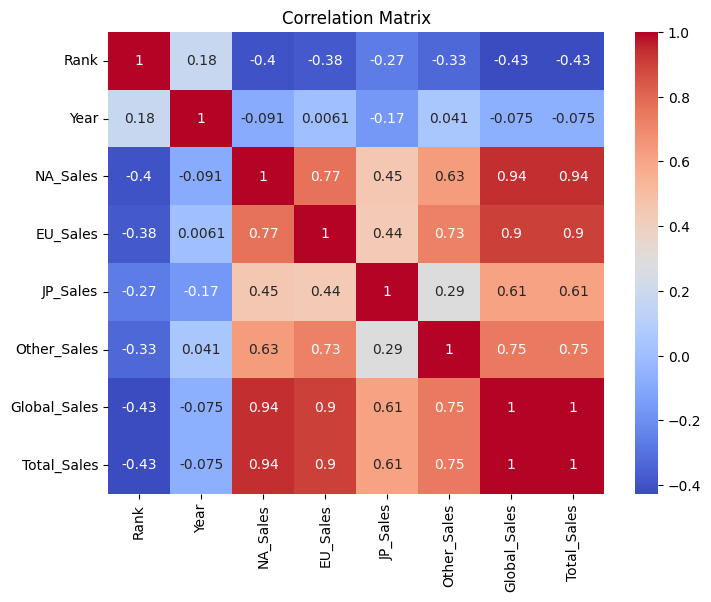

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Firmaların Satışları**

In [18]:
df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64